# 参数优化与有效前沿分析

In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import warnings
from scipy.optimize import minimize, differential_evolution
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

# 环境设置
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "font.sans-serif": ["WenQuanYi Micro Hei", "SimHei"], 
    "axes.unicode_minus": False, 
    "font.size": 12})

## 1. 数据读取与预处理

In [2]:
# 读取并处理数据
data_path = "/home/haris/project/backtester/para_optimizer_gp/results/optimization_history_trade_support7.json"
with open(data_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.json_normalize(data)

# 列名标准化
column_mapping = {
    "信息比率": "ir", "超额年化收益": "exret", "超额年化波动": "exstd",
    "年化收益": "ret", "最大回撤": "mdd", "超额最大回撤": "exmdd",
    "时间戳": "timestamp", "参数.CITIC_LIMIT": "param_citic_limit",
    "参数.CMVG_LIMIT": "param_cmvg_limit", "参数.STK_HOLD_LIMIT": "param_stock_hold_limit",
    "参数.OTHER_LIMIT": "param_other_limit", "参数.STK_BUY_R": "param_stock_buy_ratio",
    "参数.TURN_MAX": "param_turnover_max", "参数.MEM_HOLD": "param_memory_hold",
}

df = df.rename(columns=column_mapping)
print(f"数据形状: {df.shape}")
display(df.head())

数据形状: (832, 14)


,ir,exret,exstd,ret,mdd,exmdd,timestamp,param_citic_limit,param_cmvg_limit,param_stock_hold_limit,param_other_limit,param_stock_buy_ratio,param_turnover_max,param_memory_hold
0,1.412535,0.138742,0.098222,0.181110,0.349501,0.095413,2025-12-18T16:07:23.310438,0.398271,0.091717,0.015814,0.298425,0.009471,0.046996,0.183700
1,1.046541,0.062544,0.059763,0.104912,0.382096,0.066327,2025-12-18T16:15:07.262742,0.166854,0.071433,0.013367,0.028206,0.014718,0.189554,0.000312
2,1.406302,0.072453,0.051520,0.114821,0.380363,0.050079,2025-12-18T16:23:48.473285,0.496106,0.308741,0.012621,0.003533,0.001438,0.119212,0.159944
3,2.161864,0.102503,0.047414,0.144871,0.348458,0.050620,2025-12-18T16:32:30.797688,0.023333,0.486878,0.005423,0.045303,0.012749,0.095019,0.393292
4,1.717902,0.166020,0.096641,0.208388,0.311102,0.098948,2025-12-18T16:40:59.384709,0.233381,0.429970,0.013926,0.225250,0.001252,0.190174,0.225315


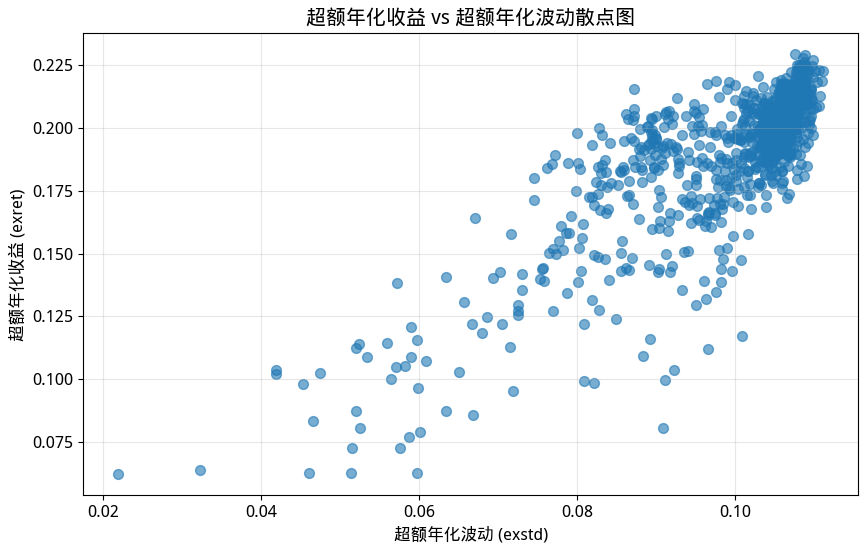

In [3]:
# 原始数据可视化
plt.figure(figsize=(10, 6))
plt.scatter(df['exstd'], df['exret'], alpha=0.6, s=50)
plt.xlabel('超额年化波动 (exstd)')
plt.ylabel('超额年化收益 (exret)')
plt.title('超额年化收益 vs 超额年化波动散点图')
plt.grid(True, alpha=0.3)
plt.show()

## 2. 上凸包计算

In [4]:
def get_upper_convex_hull(points, eps=0.01):
    """
    eps > 0 : 更宽松
    eps = 0 : 标准上凸包
    eps < 0 : 更严格
    """
    points = sorted(points, key=lambda p: (p[0], -p[1]))
    upper_hull = []
    for point in points:
        b = np.array(point)
        if upper_hull and b[1] <= upper_hull[-1][1]:
            continue
        while len(upper_hull) >= 2:
            o = np.array(upper_hull[-2])
            a = np.array(upper_hull[-1])
            u = a - o
            v = b - o
            sin_theta = np.cross(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
            if sin_theta >= eps:
                upper_hull.pop()
            else:
                break
        upper_hull.append(point)
    return upper_hull


def is_upper_hull_point(exstd_val, exret_val, hull_points, tolerance=1e-10):
    """检查点是否在上凸包中"""
    return any(
        abs(exstd_val - hull_exstd) < tolerance and 
        abs(exret_val - hull_exret) < tolerance
        for hull_exstd, hull_exret in hull_points
    )

In [5]:
# 计算上凸包并可视化
points = list(zip(df["exstd"], df["exret"]))
upper_hull_points = get_upper_convex_hull(points)

print(f"上凸包包含 {len(upper_hull_points)} 个点")
print("上凸包点坐标:")
for i, (x, y) in enumerate(upper_hull_points):
    print(f"点 {i+1}: (exstd={x:.4f}, exret={y:.4f})")

df['is_upper_hull'] = df.apply(
    lambda row: is_upper_hull_point(row['exstd'], row['exret'], upper_hull_points), 
    axis=1
)
hull_df = df[df['is_upper_hull']].sort_values('exstd')

上凸包包含 4 个点
上凸包点坐标:
点 1: (exstd=0.0219, exret=0.0621)
点 2: (exstd=0.0799, exret=0.1982)
点 3: (exstd=0.0872, exret=0.2157)
点 4: (exstd=0.1076, exret=0.2294)


/tmp/ipykernel_1815619/2326005805.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  sin_theta = np.cross(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))


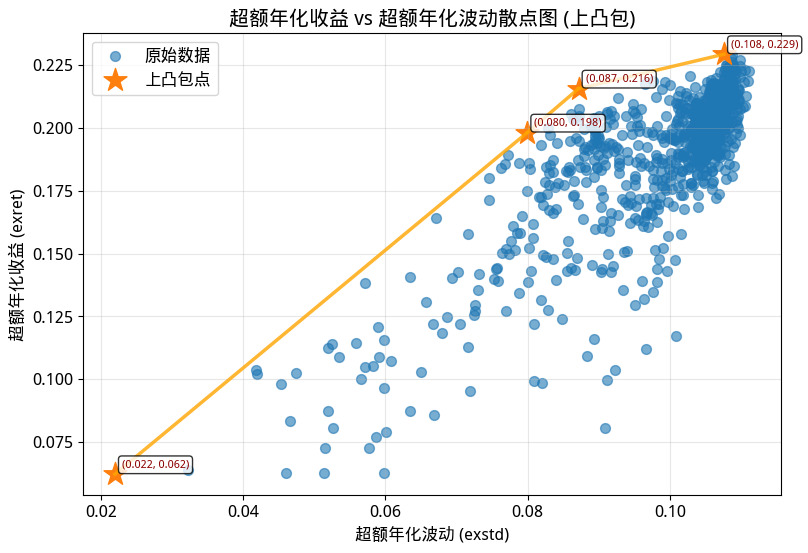

In [6]:
# 绘制上凸包
plt.figure(figsize=(9, 6))
plt.scatter(df['exstd'], df['exret'], alpha=0.6, s=50, label='原始数据')

hull_data = df[df['is_upper_hull']]
plt.scatter(hull_data['exstd'], hull_data['exret'], 
           marker='*', alpha=1, s=300, label='上凸包点')

# 绘制上凸包连线
hull_sorted = sorted(upper_hull_points, key=lambda p: p[0])
for i in range(len(hull_sorted) - 1):
    plt.plot([hull_sorted[i][0], hull_sorted[i+1][0]], 
            [hull_sorted[i][1], hull_sorted[i+1][1]], 
            '-', color='orange', alpha=0.8, linewidth=2.5)

# 添加坐标标注
for x, y in hull_sorted:
    plt.annotate(f'({x:.3f}, {y:.3f})', 
                (x, y), xytext=(5, 5), 
                textcoords='offset points', fontsize=8, 
                color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.xlabel('超额年化波动 (exstd)')
plt.ylabel('超额年化收益 (exret)')
plt.title('超额年化收益 vs 超额年化波动散点图 (上凸包)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. 上凸包的最佳逼近

In [7]:
def inverse_quadratic_model(params, y):
    """二次函数模型: x = a*y^2 + b*y + c"""
    a, b, c = params
    return a * y**2 + b * y + c


def objective_inv(params, y, x):
    """目标函数：最小化预测值与实际值的差距"""
    x_pred = inverse_quadratic_model(params, y)
    return np.sum((x_pred - x)**2)

In [8]:
# 拟合二次函数
hull_y = np.array([p[1] for p in hull_sorted])
hull_x = np.array([p[0] for p in hull_sorted])

initial_guess = [0.1, 0.1, hull_x.min()]
res_inv = minimize(objective_inv, initial_guess, args=(hull_y, hull_x))
a_fit, b_fit, c_fit = res_inv.x

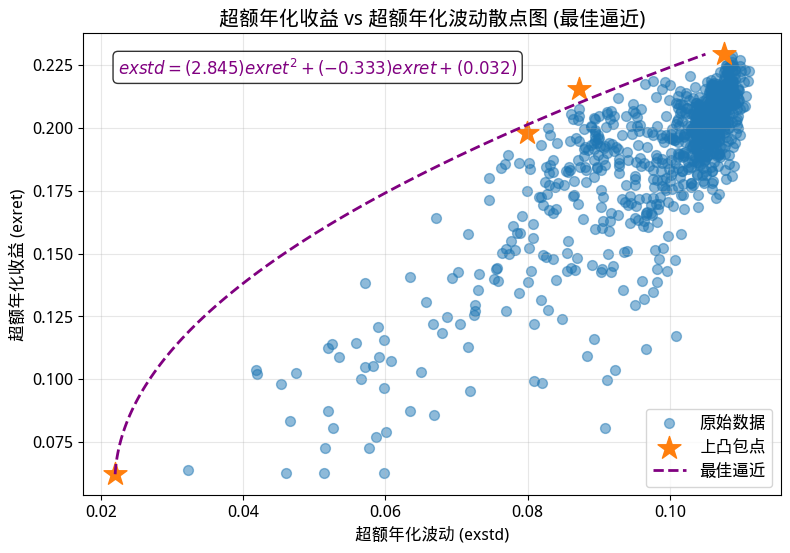

In [9]:
# 绘制拟合曲线
plt.figure(figsize=(9, 6))
plt.scatter(df["exstd"], df["exret"], alpha=0.5, s=50, label="原始数据")
plt.scatter(hull_data['exstd'], hull_data['exret'], 
           marker='*', alpha=1, s=300, label='上凸包点')

y_range = np.linspace(hull_y.min(), hull_y.max(), 100)
x_fit = inverse_quadratic_model([a_fit, b_fit, c_fit], y_range)
plt.plot(x_fit, y_range, "--", color='purple', linewidth=2, label="最佳逼近")

plt.text(0.05, 0.95,
         f"$exstd = ({a_fit:.3f}) exret^2 + ({b_fit:.3f}) exret + ({c_fit:.3f})$",
         transform=plt.gca().transAxes, fontsize=12, color="purple",
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (最佳逼近)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. 支撑超平面计算有效前沿

In [10]:
def objective_shift(shift):
    """目标函数：最小化平移向量的模长"""
    dx, dy = shift
    return dx**2 + dy**2


def constraint_shift(shift, h_x, h_y, a, b, c):
    """约束条件：平移后的曲线必须在所有凸包点的左侧"""
    dx, dy = shift
    residuals = h_x - (a * (h_y - dy)**2 + b * (h_y - dy) + c + dx)
    return residuals

In [11]:
# 优化有效前沿
initial_guess = [0, 0]
cons = {'type': 'ineq', 'fun': constraint_shift, 'args': (hull_x, hull_y, a_fit, b_fit, c_fit)}
res_opt = minimize(objective_shift, initial_guess, constraints=cons, method='SLSQP')
dx_opt, dy_opt = res_opt.x

# 计算最终参数
a_final = a_fit
b_final = b_fit - 2 * a_fit * dy_opt
c_final = a_fit * dy_opt**2 - b_fit * dy_opt + c_fit + dx_opt

print(f"优化后复合移动距离: {np.sqrt(res_opt.fun):.6f} (dx: {dx_opt:.6f}, dy: {dy_opt:.6f})")
print(f"最终方程: exstd = {a_final:.4f}*exret^2 + {b_final:.4f}*exret + {c_final:.4f}")

优化后复合移动距离: 0.003796 (dx: -0.002850, dy: 0.002508)
最终方程: exstd = 2.8448*exret^2 + -0.3471*exret + 0.0297


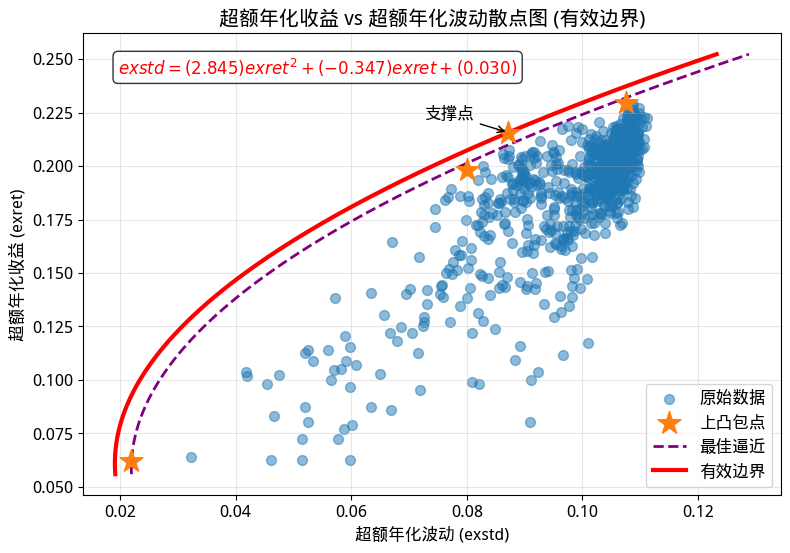

In [12]:
# 绘制有效前沿
plt.figure(figsize=(9, 6))
plt.scatter(df["exstd"], df["exret"], alpha=0.5, s=50, label="原始数据")
plt.scatter(hull_data["exstd"], hull_data["exret"], 
           marker="*", alpha=1, s=300, label="上凸包点", zorder=5)

# 生成曲线数据
y_plot = np.linspace(hull_y.min() * 0.9, hull_y.max() * 1.1, 200)
x_fit_curve = a_fit * y_plot**2 + b_fit * y_plot + c_fit
x_final_curve = a_final * y_plot**2 + b_final * y_plot + c_final

plt.plot(x_fit_curve, y_plot, "--", color="purple", linewidth=2, label="最佳逼近")
plt.plot(x_final_curve, y_plot, "r-", linewidth=3, label="有效边界")

# 标注支撑点
final_errors = hull_x - (a_final * hull_y**2 + b_final * hull_y + c_final)
touch_idx = np.argmin(final_errors)
plt.annotate("支撑点", xy=(hull_x[touch_idx], hull_y[touch_idx]),
             xytext=(-60, 10), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color="black"), zorder=6)

plt.text(0.05, 0.95,
         f"$exstd = ({a_final:.3f}) exret^2 + ({b_final:.3f}) exret + ({c_final:.3f})$",
         transform=plt.gca().transAxes, fontsize=12, color="r",
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (有效边界)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. 效率评分

In [13]:
def calculate_efficiency_score(row, a, b, c):
    """计算效率得分：有效前沿对应的最小波动率 - 实际波动率"""
    x_frontier = a * row["exret"]**2 + b * row["exret"] + c
    return x_frontier - row["exstd"]

# 计算效率得分
df["efficiency_score"] = df.apply(
    calculate_efficiency_score, args=(a_final, b_final, c_final), axis=1
)

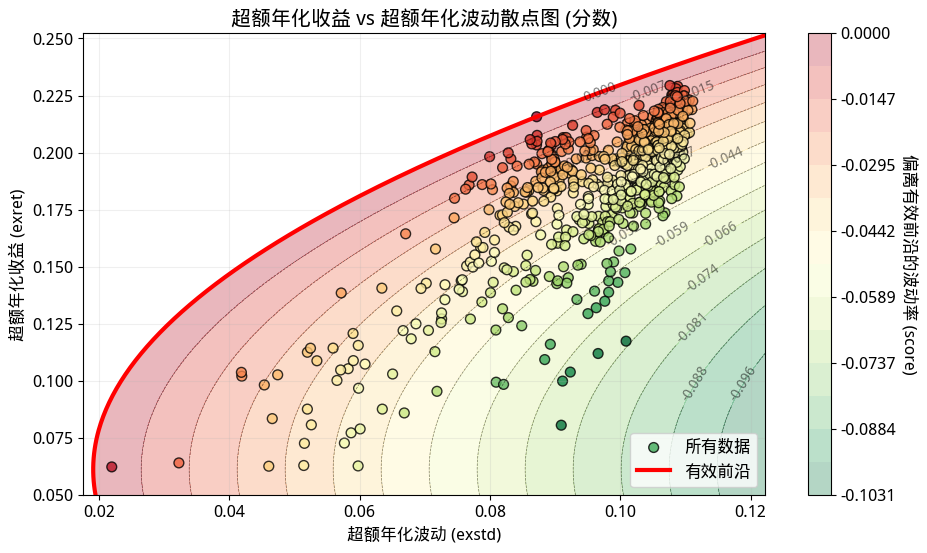

In [14]:
# 绘制效率评分热力图
x_min, x_max = df["exstd"].min() * 0.8, df["exstd"].max() * 1.1
y_min, y_max = df["exret"].min() * 0.8, df["exret"].max() * 1.1

xi, yi = np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
Xi, Yi = np.meshgrid(xi, yi)
Zi = a_final * Yi**2 + b_final * Yi + c_final - Xi

plt.figure(figsize=(11, 6))
levels = np.linspace(Zi.min(), 0, 15)
cp = plt.contourf(Xi, Yi, Zi, levels=levels, cmap="RdYlGn_r", alpha=0.3)
cbar = plt.colorbar(cp)
cbar.set_label("偏离有效前沿的波动率 (score)", rotation=270, labelpad=15)

plt.scatter(df["exstd"], df["exret"], c=df["efficiency_score"], 
           cmap="RdYlGn_r", s=50, edgecolors="k", alpha=0.8, label="所有数据")

CS = plt.contour(Xi, Yi, Zi, levels=levels, colors="k", alpha=0.5, linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10, fmt="%.3f")

y_plot = np.linspace(y_min, y_max, 200)
x_plot = a_final * y_plot**2 + b_final * y_plot + c_final
plt.plot(x_plot, y_plot, "r-", linewidth=3, label="有效前沿")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (分数)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

## 6. 参数回归分析与优化

In [15]:
# 参数设置
param_cols = [col for col in df.columns if col.startswith("param_")]
eps = 1e-8

bounds_dict = {
    "param_citic_limit": (eps, 0.5 - eps),
    "param_cmvg_limit": (eps, 0.5 - eps),
    "param_stock_hold_limit": (0.001 + eps, 0.02 - eps),
    "param_other_limit": (eps, 0.5 - eps),
    "param_stock_buy_ratio": (0.001 + eps, 0.02 - eps),
    "param_turnover_max": (0.03 + eps, 0.2 - eps),
    "param_memory_hold": (eps, 0.4 - eps),
}
param_bounds = [bounds_dict[col] for col in param_cols]

# 训练随机森林模型
X_train = df[param_cols]
y_train = df["efficiency_score"]
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
# 参数优化
search_history = []
max_iters, pop_size = 50, 20
pbar = tqdm(total=max_iters, desc="参数寻优进度")

def objective_func(params_array):
    p_df = pd.DataFrame([params_array], columns=param_cols)
    pred_score = rf_model.predict(p_df)[0]
    search_history.append({**dict(zip(param_cols, params_array)), 
                          "predicted_efficiency_score": pred_score})
    return -pred_score

def monitor_progress(xk, convergence=None):
    pbar.update(1)
    p_df = pd.DataFrame([xk], columns=param_cols)
    current_best = rf_model.predict(p_df)[0]
    pbar.set_postfix({"BestScore": f"{current_best:.6f}"})

# 执行差分进化优化
result_opt = differential_evolution(
    objective_func, param_bounds, strategy="rand1bin", init="latinhypercube",
    popsize=pop_size, maxiter=max_iters, seed=42, callback=monitor_progress,
)
pbar.close()

参数寻优进度:   0%|          | 0/50 [00:00<?, ?it/s]

In [17]:
# 分散化筛选
history_df = pd.DataFrame(search_history).drop_duplicates(subset=param_cols)
print(f"\n--- 执行分散化筛选 (候选库大小: {len(history_df)}) ---")

top_n = min(len(history_df), 2000)
top_candidates = history_df.sort_values(
    by="predicted_efficiency_score", ascending=False
).head(top_n).copy()

# K-means聚类分散化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(top_candidates[param_cols])
n_target = 100
n_clusters = min(len(top_candidates), n_target)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
top_candidates["cluster"] = kmeans.fit_predict(X_scaled)

# 提取每个簇的最佳样本
diverse_top_100 = (
    top_candidates.sort_values("predicted_efficiency_score", ascending=False)
    .groupby("cluster").head(1)
    .sort_values("predicted_efficiency_score", ascending=False)
)

# 输出结果
print(f"已提取 {len(diverse_top_100)} 组高分且空间分散的参数。")


--- 执行分散化筛选 (候选库大小: 7147) ---
已提取 100 组高分且空间分散的参数。


In [ ]:
# 保存最终结果
final_samples_df = diverse_top_100[param_cols].head(100)
final_samples_list = final_samples_df.to_dict(orient="records")

# 输出到JSON和CSV文件
json_output_path = "/home/haris/project/backtester/para_optimizer_ef/parameters/diverse_efficient_parameters_std_score_trade_support7.json"
final_samples_df.to_json(json_output_path, orient="records", force_ascii=False, indent=4)

csv_output_path = "/home/haris/project/backtester/para_optimizer_ef/parameters/diverse_efficient_parameters_std_score_trade_support7.csv"
final_samples_df.to_csv(csv_output_path, index=False, encoding="utf-8-sig")

print(f"结果已保存至:")
print(f"- JSON: {json_output_path}")
print(f"- CSV: {csv_output_path}")
print(f"\n最终参数样本数量: {len(final_samples_list)}")

结果已保存至:
- JSON: diverse_efficient_parameters_std_score_trade_support7.json
- CSV: diverse_efficient_parameters_std_score_trade_support7.csv

最终参数样本数量: 100


## 7. 实验结果

In [15]:
# 读取并处理数据
data_path = "/home/haris/project/backtester/para_optimizer_ef/scores/diverse_efficient_parameters_std_score_trade_support7.json"
with open(data_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df_exp = pd.json_normalize(data, record_path=["backtest_info"])

result_df = df_exp[["超额年化收益", "超额年化波动"]]

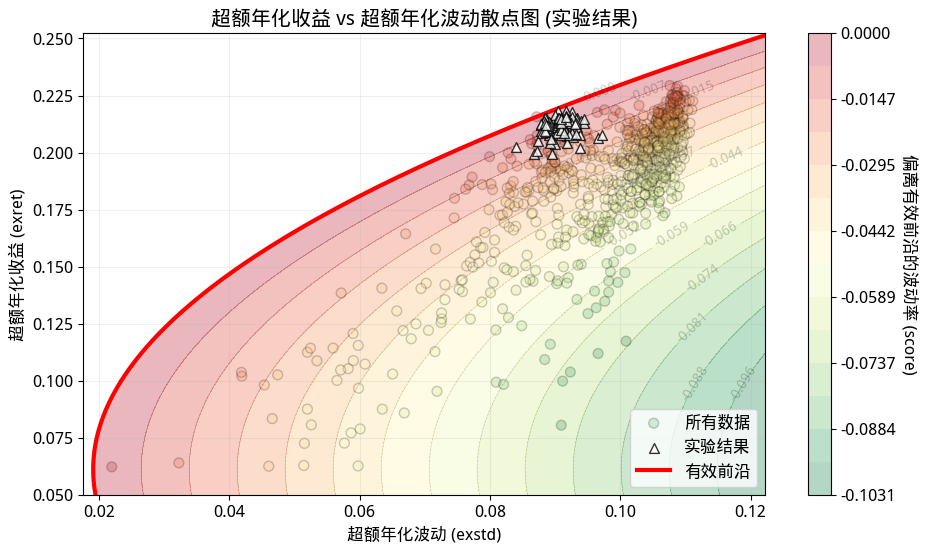

In [16]:
# 绘制效率评分热力图
x_min, x_max = df["exstd"].min() * 0.8, df["exstd"].max() * 1.1
y_min, y_max = df["exret"].min() * 0.8, df["exret"].max() * 1.1

xi, yi = np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
Xi, Yi = np.meshgrid(xi, yi)
Zi = a_final * Yi**2 + b_final * Yi + c_final - Xi

plt.figure(figsize=(11, 6))
levels = np.linspace(Zi.min(), 0, 15)
cp = plt.contourf(Xi, Yi, Zi, levels=levels, cmap="RdYlGn_r", alpha=0.3)
cbar = plt.colorbar(cp)
cbar.set_label("偏离有效前沿的波动率 (score)", rotation=270, labelpad=15)

plt.scatter(df["exstd"], df["exret"], c=df["efficiency_score"], 
           cmap="RdYlGn_r", s=50, edgecolors="k", alpha=0.2, label="所有数据")
plt.scatter(result_df["超额年化波动"], result_df["超额年化收益"], c="w", marker="^", alpha=0.8, s=50, edgecolors="k", label="实验结果", zorder=10)

CS = plt.contour(Xi, Yi, Zi, levels=levels, colors="k", alpha=0.2, linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10, fmt="%.3f")

y_plot = np.linspace(y_min, y_max, 200)
x_plot = a_final * y_plot**2 + b_final * y_plot + c_final
plt.plot(x_plot, y_plot, "r-", linewidth=3, label="有效前沿")

plt.xlim(x_min, x_max)
plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (实验结果)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()